In [1]:
# STEP 1: Load and inspect
import pandas as pd
import numpy as np

df = pd.read_csv("creditcard.csv")

print("Shape:", df.shape)
print("\n--- First 5 rows ---")
print(df.head())

print("\n--- Columns ---")
print(df.columns.tolist())

print("\n--- Info ---")
df.info()

print("\n--- Missing values (total) ---")
print(df.isnull().sum().sum())

# --- The critical one: class balance ---
print("\n--- Class distribution ---")
print(df['Class'].value_counts())
print(df['Class'].value_counts(normalize=True).round(5))

fraud = df['Class'].sum()
total = len(df)
print(f"\nFraud cases: {fraud} out of {total}  ({fraud/total*100:.3f}%)")

Shape: (31780, 31)

--- First 5 rows ---
   Time        V1        V2        V3        V4        V5        V6        V7  \
0     0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1     0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2     1 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3     1 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4     2 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.20

In [2]:
# STEP 2: Inspect & handle missing values

# --- Which rows have missing values? ---
missing_rows = df[df.isnull().any(axis=1)]
print("Rows with any missing value:", len(missing_rows))
print(missing_rows)

# --- Missing per column ---
print("\nMissing per column (only those > 0):")
print(df.isnull().sum()[df.isnull().sum() > 0])

Rows with any missing value: 1
        Time        V1        V2        V3        V4      V5       V6  V7  V8  \
31779  36513  1.295137  0.096775  0.348134  0.629896 -0.1727 -0.15435 NaN NaN   

       V9  ...  V21  V22  V23  V24  V25  V26  V27  V28  Amount  Class  
31779 NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN     NaN    NaN  

[1 rows x 31 columns]

Missing per column (only those > 0):
V7        1
V8        1
V9        1
V10       1
V11       1
V12       1
V13       1
V14       1
V15       1
V16       1
V17       1
V18       1
V19       1
V20       1
V21       1
V22       1
V23       1
V24       1
V25       1
V26       1
V27       1
V28       1
Amount    1
Class     1
dtype: int64


In [3]:
# STEP 2 (cont.): Drop the corrupted row & finalize

# Drop rows where Class is missing (can't train without a label)
df = df.dropna().reset_index(drop=True)

# Cast Class to int (was float 0.0/1.0)
df['Class'] = df['Class'].astype(int)

# --- Verify ---
print("Shape after cleaning:", df.shape)
print("Total missing now:", df.isnull().sum().sum())
print("\nClass distribution:")
print(df['Class'].value_counts())
fraud = df['Class'].sum()
print(f"\nFraud: {fraud} / {len(df)}  ({fraud/len(df)*100:.3f}%)")

Shape after cleaning: (31779, 31)
Total missing now: 0

Class distribution:
Class
0    31677
1      102
Name: count, dtype: int64

Fraud: 102 / 31779  (0.321%)


/tmp/ipykernel_1275/1657764843.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Legit (0)', 'Fraud (1)'])
/tmp/ipykernel_1275/1657764843.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Legit (0)', 'Fraud (1)'])


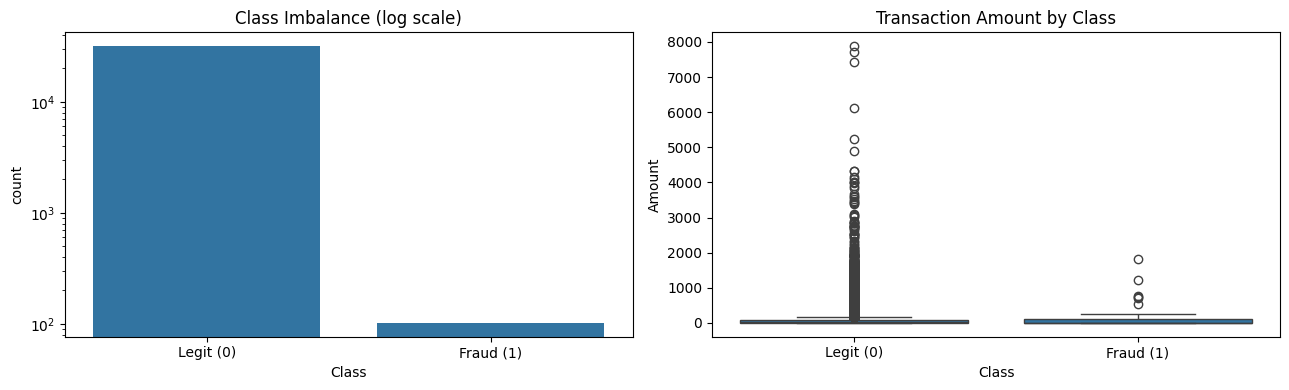

--- Amount by class ---
         count   mean     std  min   25%    50%    75%      max
Class                                                          
0      31677.0  81.08  223.07  0.0  6.87  20.00  73.61  7879.42
1        102.0  91.24  248.27  0.0  1.00   3.44  99.99  1809.68


In [4]:
# STEP 3a: Class imbalance + Amount/Time by class
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class imbalance (log scale so fraud bar is visible)
sns.countplot(x='Class', data=df, ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Class Imbalance (log scale)')
axes[0].set_xticklabels(['Legit (0)', 'Fraud (1)'])

# Amount distribution by class
sns.boxplot(x='Class', y='Amount', data=df, ax=axes[1])
axes[1].set_title('Transaction Amount by Class')
axes[1].set_xticklabels(['Legit (0)', 'Fraud (1)'])
plt.tight_layout()
plt.show()

# --- Amount stats by class ---
print("--- Amount by class ---")
print(df.groupby('Class')['Amount'].describe().round(2))

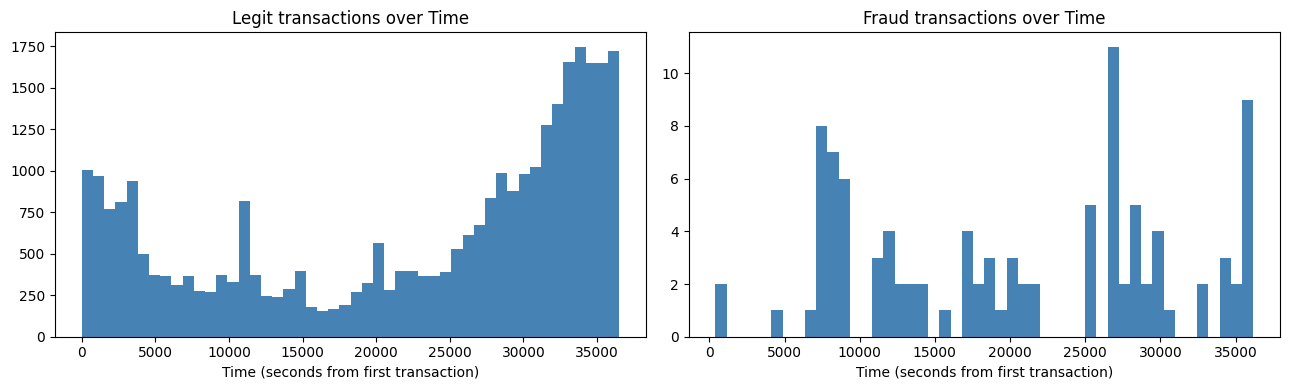

In [5]:
# --- Time pattern: when do fraud vs legit happen? ---
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for cls, ax, title in zip([0, 1], axes, ['Legit', 'Fraud']):
    ax.hist(df[df['Class'] == cls]['Time'], bins=48, color='steelblue')
    ax.set_title(f'{title} transactions over Time')
    ax.set_xlabel('Time (seconds from first transaction)')
plt.tight_layout()
plt.show()

In [6]:
# STEP 3b: Which V-features separate fraud best?

# Correlation of every feature with Class
corr_with_class = df.corr()['Class'].drop('Class').sort_values(key=abs, ascending=False)
print("--- Features ranked by |correlation| with Class ---")
print(corr_with_class.round(3))

--- Features ranked by |correlation| with Class ---
V17      -0.424
V3       -0.420
V14      -0.411
V7       -0.338
V10      -0.328
V12      -0.305
V16      -0.300
V11       0.248
V1       -0.231
V4        0.228
V5       -0.214
V2        0.214
V18      -0.184
V8        0.174
V9       -0.150
V27       0.116
V6       -0.103
V20       0.054
V21       0.049
V19       0.034
V23      -0.029
V24      -0.024
V25       0.023
V28       0.022
V22      -0.021
V26       0.017
Time     -0.009
V15      -0.006
V13       0.003
Amount    0.003
Name: Class, dtype: float64


Top 6 separating features: ['V17', 'V3', 'V14', 'V7', 'V10', 'V12']


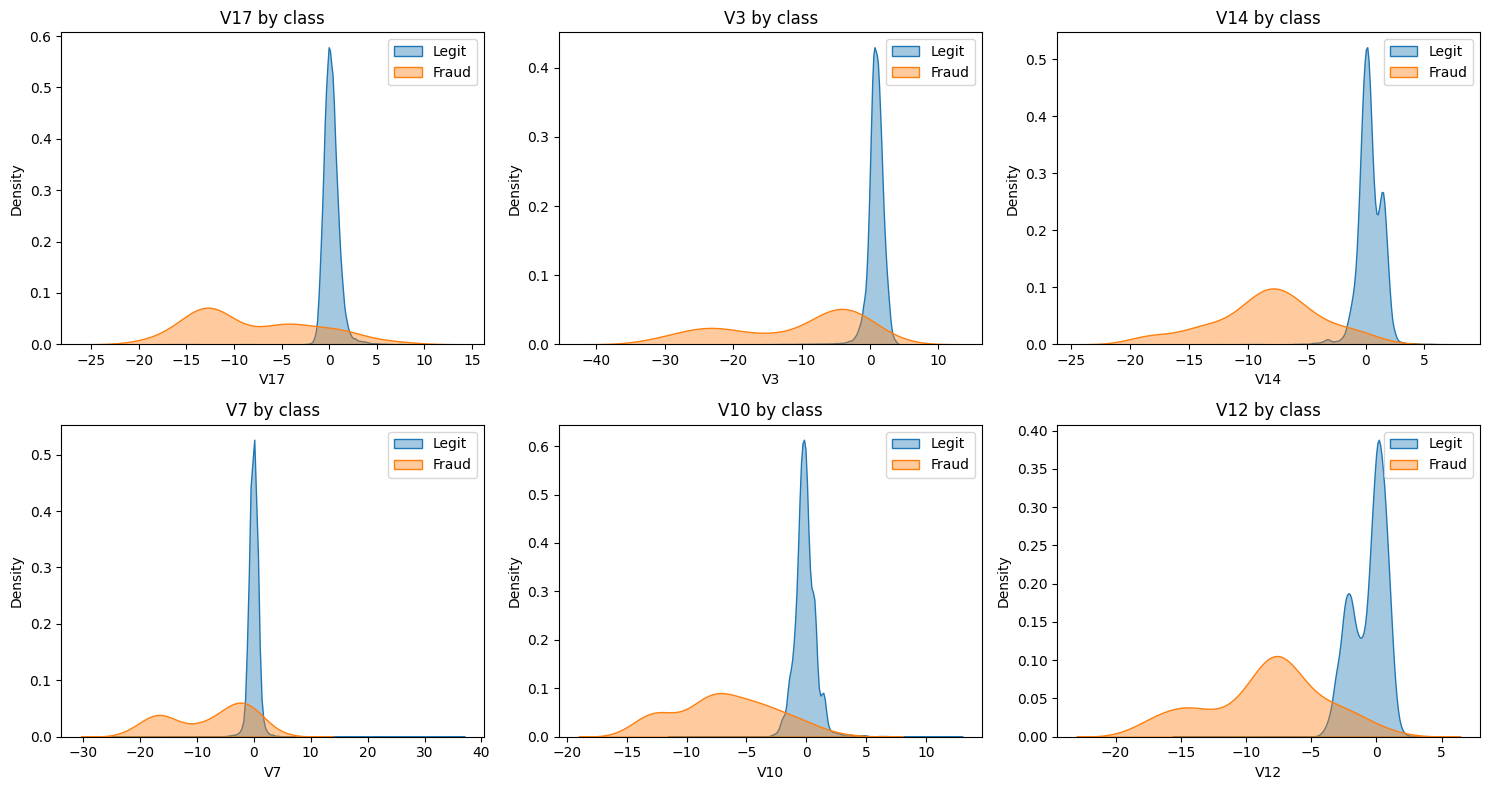

In [7]:
# --- Visualize the distribution split for the top separating features ---
top_feats = corr_with_class.head(6).index.tolist()
print("Top 6 separating features:", top_feats)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, feat in zip(axes.flatten(), top_feats):
    sns.kdeplot(data=df[df['Class']==0], x=feat, ax=ax, label='Legit', fill=True, alpha=0.4)
    sns.kdeplot(data=df[df['Class']==1], x=feat, ax=ax, label='Fraud', fill=True, alpha=0.4)
    ax.set_title(f'{feat} by class')
    ax.legend()
plt.tight_layout()
plt.show()

In [8]:
# STEP 4: Scale Amount/Time + stratified split
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- Scale Amount and Time (V1-V28 already PCA-scaled) ---
scaler = StandardScaler()
df['Amount_scaled'] = scaler.fit_transform(df[['Amount']])
df['Time_scaled']   = scaler.fit_transform(df[['Time']])

# Drop the originals; keep scaled versions
df_model = df.drop(columns=['Amount', 'Time'])

# --- Features / target ---
X = df_model.drop(columns=['Class'])
y = df_model['Class']

# --- Stratified split (keeps fraud ratio in both sets) ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nTrain fraud:", y_train.sum(), f"({y_train.mean()*100:.3f}%)")
print("Test  fraud:", y_test.sum(),  f"({y_test.mean()*100:.3f}%)")

Train: (25423, 30)  Test: (6356, 30)

Train fraud: 82 (0.323%)
Test  fraud: 20 (0.315%)


In [9]:
# STEP 5: SMOTE on training set only
# Install imbalanced-learn if needed
try:
    from imblearn.over_sampling import SMOTE
except ImportError:
    !pip install imbalanced-learn -q
    from imblearn.over_sampling import SMOTE

print("BEFORE SMOTE (train):")
print(y_train.value_counts())

# SMOTE creates synthetic fraud rows to balance the TRAINING data
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAFTER SMOTE (train):")
print(y_train_smote.value_counts())
print("New training shape:", X_train_smote.shape)

# Test set stays UNTOUCHED
print("\nTest set unchanged — fraud:", y_test.sum(), f"({y_test.mean()*100:.3f}%)")

BEFORE SMOTE (train):
Class
0    25341
1       82
Name: count, dtype: int64

AFTER SMOTE (train):
Class
0    25341
1    25341
Name: count, dtype: int64
New training shape: (50682, 30)

Test set unchanged — fraud: 20 (0.315%)


In [10]:
# STEP 6: Train & evaluate all models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix)
try:
    from xgboost import XGBClassifier
except ImportError:
    !pip install xgboost -q
    from xgboost import XGBClassifier

# scale_pos_weight for XGBoost class-weight flavor (ratio of legit:fraud)
spw = (y_train == 0).sum() / (y_train == 1).sum()

# --- Define models in two flavors ---
models = {
    # (a) trained on SMOTE-balanced data
    'LogReg (SMOTE)':      (LogisticRegression(max_iter=1000), X_train_smote, y_train_smote),
    'RandomForest (SMOTE)':(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1), X_train_smote, y_train_smote),
    'XGBoost (SMOTE)':     (XGBClassifier(n_estimators=200, random_state=42, verbosity=0, eval_metric='logloss'), X_train_smote, y_train_smote),
    # (b) trained on original data with class weighting
    'LogReg (weighted)':   (LogisticRegression(max_iter=1000, class_weight='balanced'), X_train, y_train),
    'RandomForest (weighted)':(RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1, class_weight='balanced'), X_train, y_train),
    'XGBoost (weighted)':  (XGBClassifier(n_estimators=200, random_state=42, verbosity=0, eval_metric='logloss', scale_pos_weight=spw), X_train, y_train),
}

# --- Train each, evaluate on the UNTOUCHED test set ---
results = []
trained = {}
for name, (model, Xtr, ytr) in models.items():
    model.fit(Xtr, ytr)
    trained[name] = model
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    results.append({
        'Model':     name,
        'Precision': round(precision_score(y_test, y_pred), 3),
        'Recall':    round(recall_score(y_test, y_pred), 3),
        'F1':        round(f1_score(y_test, y_pred), 3),
        'ROC_AUC':   round(roc_auc_score(y_test, y_proba), 3),
    })

results_df = pd.DataFrame(results).sort_values('F1', ascending=False).reset_index(drop=True)
print(results_df.to_string(index=False))

                  Model  Precision  Recall    F1  ROC_AUC
RandomForest (weighted)      0.941    0.80 0.865    0.974
   RandomForest (SMOTE)      0.850    0.85 0.850    0.973
        XGBoost (SMOTE)      0.850    0.85 0.850    0.998
     XGBoost (weighted)      0.810    0.85 0.829    0.984
         LogReg (SMOTE)      0.147    0.95 0.255    0.979
      LogReg (weighted)      0.146    0.95 0.253    0.978


=== RandomForest (weighted) ===
              precision    recall  f1-score   support

       Legit       1.00      1.00      1.00      6336
       Fraud       0.94      0.80      0.86        20

    accuracy                           1.00      6356
   macro avg       0.97      0.90      0.93      6356
weighted avg       1.00      1.00      1.00      6356



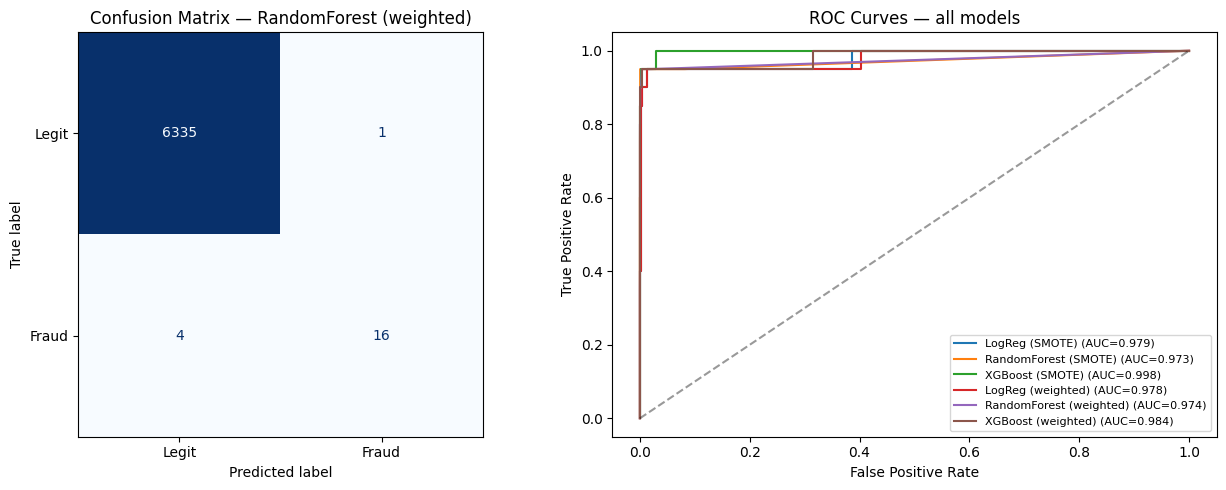

In [11]:
# STEP 7: Deep-dive on the best model
from sklearn.metrics import ConfusionMatrixDisplay, roc_curve, classification_report

best_name = 'RandomForest (weighted)'
best_model = trained[best_name]
y_pred  = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(f"=== {best_name} ===")
print(classification_report(y_test, y_pred, target_names=['Legit', 'Fraud']))

# --- Confusion matrix + ROC curve side by side ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Legit', 'Fraud']).plot(
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Confusion Matrix — {best_name}')
axes[0].grid(False)

# ROC curves for all models
for name, model in trained.items():
    proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[1].plot(fpr, tpr, label=f'{name} (AUC={auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', alpha=0.4)
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — all models')
axes[1].legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

--- Top 10 features ---
V14    0.209
V3     0.137
V4     0.119
V17    0.088
V10    0.082
V11    0.081
V12    0.069
V16    0.041
V2     0.039
V7     0.021
dtype: float64


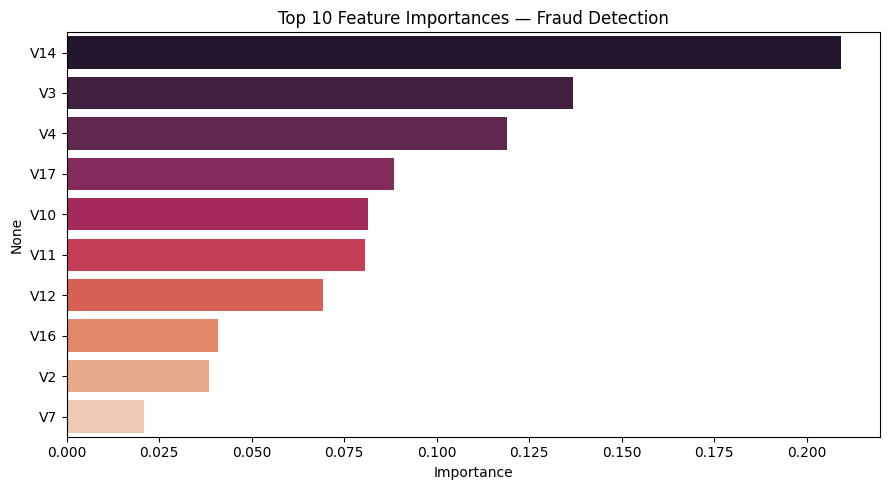

In [12]:
# --- Feature importance (which V's drive fraud detection) ---
importances = pd.Series(best_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("--- Top 10 features ---")
print((importances.head(10)).round(3))

plt.figure(figsize=(9, 5))
sns.barplot(x=importances.head(10).values, y=importances.head(10).index,
            hue=importances.head(10).index, palette='rocket', legend=False)
plt.title('Top 10 Feature Importances — Fraud Detection')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

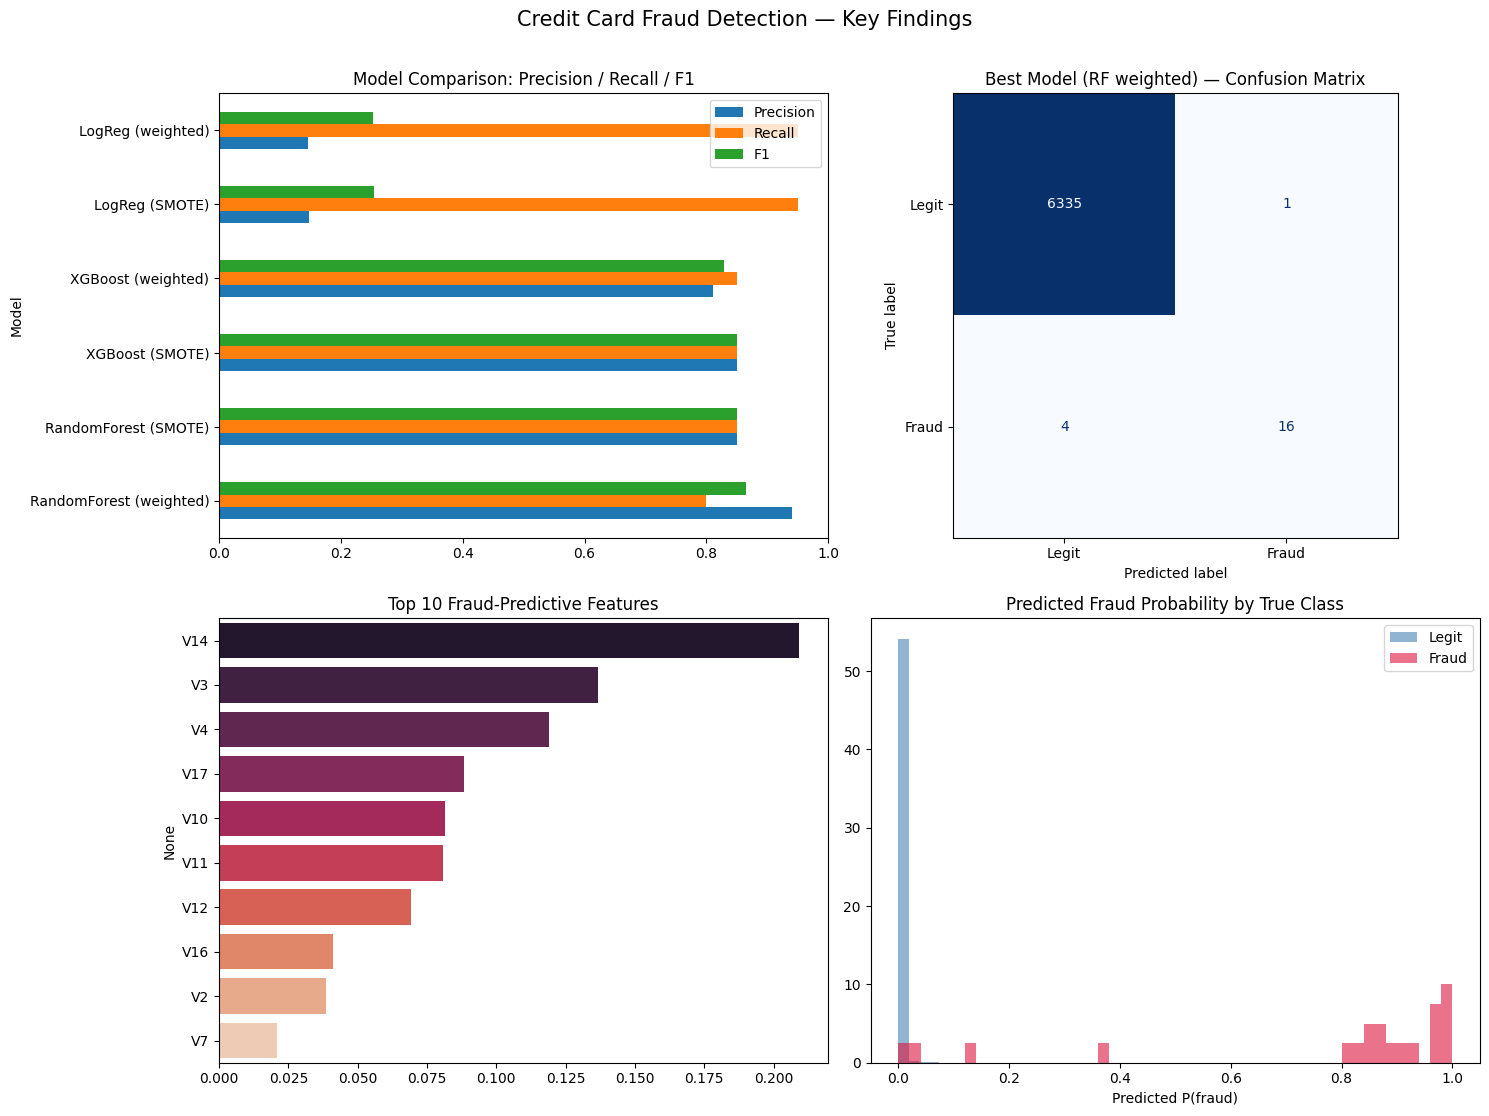

In [13]:
# STEP 8: Dashboard-style summary panel
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# (1) Model comparison — F1 & Recall
m = results_df.set_index('Model')[['Precision','Recall','F1']]
m.plot(kind='barh', ax=axes[0,0])
axes[0,0].set_title('Model Comparison: Precision / Recall / F1')
axes[0,0].set_xlim(0, 1)

# (2) Confusion matrix of best model
ConfusionMatrixDisplay(cm, display_labels=['Legit','Fraud']).plot(
    cmap='Blues', ax=axes[0,1], colorbar=False)
axes[0,1].set_title('Best Model (RF weighted) — Confusion Matrix')
axes[0,1].grid(False)

# (3) Top feature importances
top10 = importances.head(10)
sns.barplot(x=top10.values, y=top10.index, hue=top10.index,
            palette='rocket', legend=False, ax=axes[1,0])
axes[1,0].set_title('Top 10 Fraud-Predictive Features')

# (4) Fraud probability distribution (best model)
axes[1,1].hist(y_proba[y_test==0], bins=50, alpha=0.6, label='Legit', color='steelblue', density=True)
axes[1,1].hist(y_proba[y_test==1], bins=50, alpha=0.6, label='Fraud', color='crimson', density=True)
axes[1,1].set_title('Predicted Fraud Probability by True Class')
axes[1,1].set_xlabel('Predicted P(fraud)')
axes[1,1].legend()

plt.suptitle('Credit Card Fraud Detection — Key Findings', fontsize=15, y=1.01)
plt.tight_layout()
plt.show()